# Regression - Excercise

```In this exercise you will experience with simple features of the linear and logistic regressions, and will get to know some interesting features of those regressions.```

~```Ittai Haran```

In [209]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

## Coefficients and some more

```We will start by exploring several concepts regarding linear and logistic regression. To that matter, we will prefer working using a generated dataset. Start by generating (using numpy and np.random) the following dataset:```

$X \sim \cal N(0,1)^3$ ```(i.e X consists of 3-dimensional vectors)```

$Y = 0.3\cdot X[:,0] + 0.5\cdot X[:,1] - 0.7\cdot X[:,2] + 1$

```Generate 1,000 samples.```

In [210]:
N = 1000
gen = np.random.default_rng()
X = gen.standard_normal(size=(N, 3))
Y = 0.3 * X[:, 0] + 0.5 * X[:, 1] - 0.7 * X[:, 2] + 1

```Train a simple linear regression (sklearn.linear_model.LinearRegression) on the data. What coefficients did you get using your regression? Did you expect those coefficients?```

In [211]:
reg = sklearn.linear_model.LinearRegression().fit(X, Y)
reg.coef_, reg.intercept_


(array([ 0.3,  0.5, -0.7]), np.float64(1.0))

```We will now conduct a similar experiment, only this time using logistic regression, with minor adjustments:```

$X \sim \cal N(0,1)^3$ ```(i.e X consists of 3-dimensional vectors)```

$Y = (0.3\cdot X[:,0] + 0.5\cdot X[:,1] - 0.7\cdot X[:,2] \geq 1)$

```Generate 1,000 samples.```

In [212]:
N = 1000
gen = np.random.default_rng()
X = gen.standard_normal(size=(N, 3))
Y = np.sign(0.3 * X[:, 0] + 0.5 * X[:, 1] - 0.7 * X[:, 2] - 1)

```Train a simple logistic regression (sklearn.linear_model.LogisticRegression) on the data. What coefficients did you get using your logistic regression? Did you expect those coefficients? Why, or why not?```

In [213]:
reg = sklearn.linear_model.LogisticRegression().fit(X, Y)
reg.coef_, reg.intercept_


(array([[ 2.3370792 ,  3.66616135, -5.51060987]]), array([-7.98946632]))

```Repeat this experiment, this time with 10,000 samples and 100,000 samples. Did you get different coefficients? Why or why not?```

In [214]:
for N in (10000, 100000):
    gen = np.random.default_rng()
    X = gen.standard_normal(size=(N, 3))
    Y = np.sign(0.3 * X[:, 0] + 0.5 * X[:, 1] - 0.7 * X[:, 2] - 1)
    reg = sklearn.linear_model.LogisticRegression().fit(X, Y)
    print(reg.coef_, reg.intercept_)


[[  5.02490655   8.50979479 -11.91371041]] [-17.09230562]
[[ 10.85959254  18.06788806 -25.23225441]] [-36.17522506]


## Non-linear linear regressions

```Load the data in func_1_train.csv.
Can be found in: https://drive.google.com/open?id=1y3HtVk0N1q4xYn_qczDcdkZfGpy23z9l```

In [215]:
df = pd.read_csv('func_1_train.csv')

```Draw a scatter plot of y as a function of x. What kind of functions would you like to fit here?```

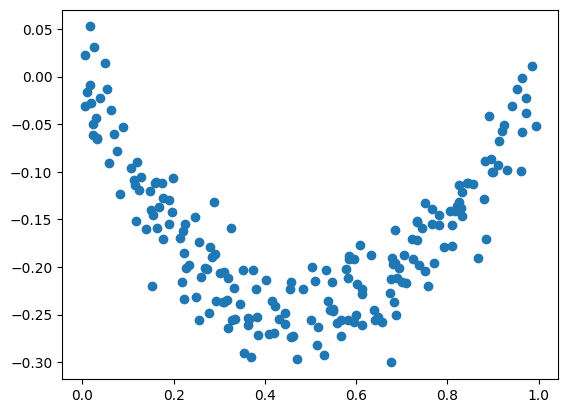

In [216]:
plt.scatter(df['x'], df['y'])

```Try fitting a linear regression. Draw the data points and the function you fitted on the same plot.```

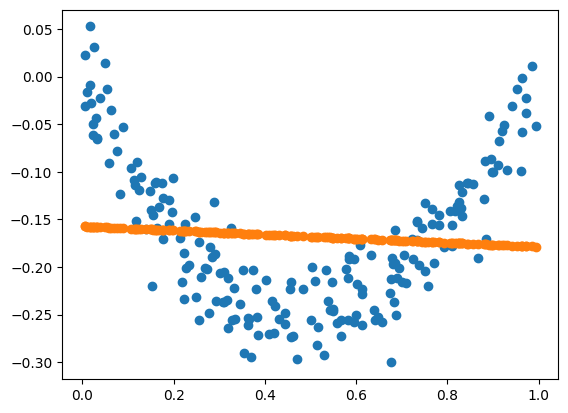

In [217]:
def ex_data(df):
    X = df['x'].to_numpy().reshape(
    (len(df['x']), 1)
    )
    Y = df['y'].to_numpy().reshape(
    (len(df['y']), 1)
    )
    return X, Y
X, Y = ex_data(df)
reg = sklearn.linear_model.LinearRegression().fit(X, Y)
plt.scatter(df['x'], df['y'])
plt.scatter(df['x'], reg.predict(X))

In [218]:
def poly_reg(df):
    x, Y = ex_data(df)
    X = np.concatenate(
        [x**i for i in range(1, 50)],
        axis=1
    )
    reg = sklearn.linear_model.LinearRegression().fit(X, Y)
    plt.scatter(df['x'], df['y'])
    plt.scatter(df['x'], reg.predict(X))

```Let's do some feature extraction. Create a dataset with the features (X, X**2, X**3, ..., X**49). Now try fitting a linear regression using your new dataset. Draw your results on the same graph as before. Judge your results using func_1_test and using the mean squared error metric.```

```Can be found in: https://drive.google.com/open?id=1ipm09QTjVZWFgh-zc70rxWLGPWYEt1Kb```

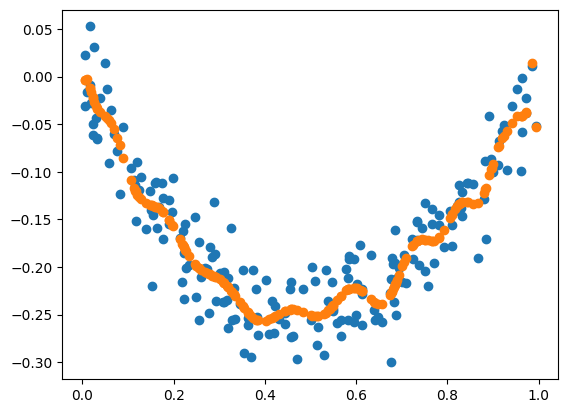

In [219]:
df_train = pd.read_csv('func_1_train.csv')
poly_reg(df_train)


```How come you could a model that isn't under fitted? You did still use a linear regression. Can you explain those results? However, your model seemed to be over fitted (why?). Why is that?```

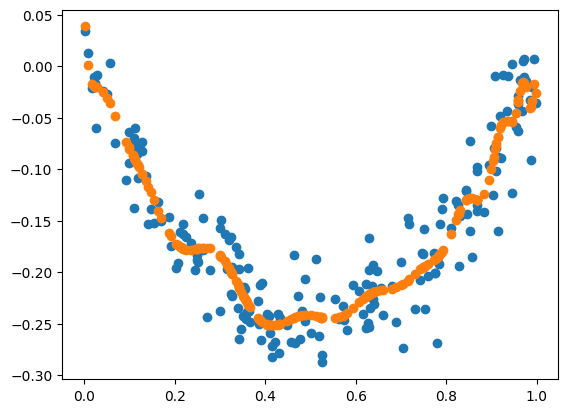

In [220]:
df_test = pd.read_csv('func_1_test.csv')
poly_reg(df_test)

```You can try using a regularized regression to avoid over fitting. Use sklearn.linear_model.Ridge with different alphas until you get nice fit (judge it using your plots and using func_1_test and the mean squared error metric). Could you get better results?```

0.012308707942531923


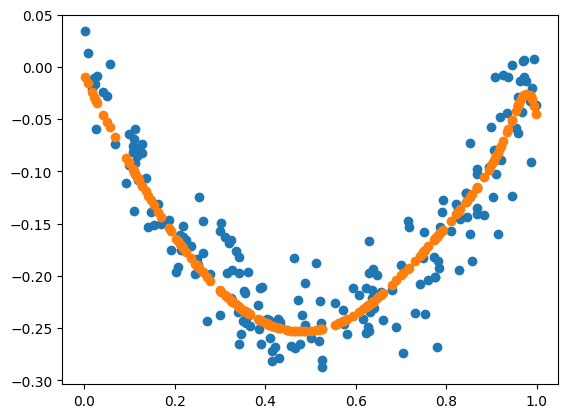

In [221]:
df_train = pd.read_csv('func_1_train.csv')
x, Y = ex_data(df_train)
X = np.concatenate(
    [x**i for i in range(1, 50)],
    axis=1
)
reg = sklearn.linear_model.Ridge(alpha=0.01)
reg.fit(X, Y)
df_test = pd.read_csv('func_1_test.csv')
x, Y = ex_data(df_test)
X = np.concatenate(
    [x**i for i in range(1, 50)],
    axis=1
)
print(np.mean((reg.predict(X) - Y)**2))
plt.scatter(df_test['x'], df_test['y'])
plt.scatter(df_test['x'], reg.predict(X))

## Working on a real life data

```Start by loading house_data.csv. For our current purposes we will need only the numeric columns. Take only the numeric columns, using pandas.DataFrame.dtypes. Use fillna(0) to get rid of nans (the the column Id. can tell why?).```

```Can be found in: https://drive.google.com/open?id=1ID2h8mzjXLRbay5pE0QN1v5-jc86203L```

In [222]:
df = pd.read_csv('house_data.csv')
df = df.select_dtypes(include=[np.number]).fillna(0)

In [223]:
def in_out(df_train, df_split):
    x_train = df_train.drop(columns=['SalePrice'])
    x_test = df_test.drop(columns=['SalePrice'])
    y_train = df_train['SalePrice']
    y_test = df_test['SalePrice']
    return x_train, x_test, y_train, y_test

```We would like to predict the SalePrice columns. Create, using your data, the features dataset and the target dataset. Use sklearn.model_selection.train_test_split and create a train segment of 0.7 of your data and test segment of 0.3 of your data.```

In [224]:
df_train, df_test = sklearn.model_selection.train_test_split(df, test_size=0.3)
x_train, x_test, y_train, y_test = in_out(df_train, df_test)

```Try fitting the best linear regression you can (evaluate yourself using mean squared error). You can also use ridge regression with different alphas.```

In [225]:
def fit(x_train, x_test, y_train, y_test):
    N = len(y_train)
    M = len(y_test)
    train_errors = [] 
    test_errors = [] 

    for K in range(1, 5):
        poly = sklearn.preprocessing.PolynomialFeatures(K, include_bias=False)
        X_train = x_train.to_numpy()
        Y_train = y_train.to_numpy().reshape((N,1))
        X_train_poly = poly.fit_transform(X_train)
        scaler = sklearn.preprocessing.StandardScaler().fit(X_train_poly)
        X_train_poly = scaler.transform(X_train_poly)
        reg = sklearn.linear_model.Ridge(alpha=0).fit(X_train_poly, Y_train)
        X_test = x_test.to_numpy()
        Y_test = y_test.to_numpy().reshape((M,1))
        X_test_poly = poly.transform(X_test)
        X_test_poly = scaler.transform(X_test_poly)
        mse_train = sklearn.metrics.mean_squared_error(Y_train, reg.predict(X_train_poly))
        mse_test = sklearn.metrics.mean_squared_error(Y_test, reg.predict(X_test_poly))
        train_errors.append(mse_train)
        test_errors.append(mse_test)
    print(np.argmin(train_errors), np.argmin(test_errors))
    print(min(test_errors))
fit(x_train, x_test, y_train, y_test)

c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.791738837534695e-18.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


2 0
1858668882.9282124


```If you would look closely, you will find out that you dropped the columns LotShape and LandContour. This time try not dropping them, and instead replace them with a 1-hot encoding of them (consider``` [pandas.get_dummies](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html))```.
Try getting better results on the test segment using your ridge regressions. compare the new results with the old ones.```

In [226]:
df = pd.read_csv('house_data.csv')
df = pd.get_dummies(df, columns=['LandContour', 'LotShape'], dtype=int)
df = df.select_dtypes(include=[np.number]).fillna(0)
df_train, df_test = sklearn.model_selection.train_test_split(df, test_size=0.3)

x_train, x_test, y_train, y_test = in_out(df_train, df_test)

fit(x_train, x_test, y_train, y_test)


c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.487971482783629e-19.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


3 0
1524629282.971731


```Now add more features to your dataframe:```
- ```LotArea in squared meters ( it's currently in units of squared feet)```
- ```1stFlrSF + 2ndFlrSF```
- ```GarageArea**0.5```
- ```LotArea / (BedroomAbvGr+1)```
- ```LotArea / (mean LotArea for houses built in that same year + 1e-5) - you might want to use``` [pandas merge function](https://www.google.com/search?q=pandas+merge&oq=pandas+merge&aqs=chrome..69i57l2j69i59l3j69i60.2080j0j9&sourceid=chrome&ie=UTF-8)
- ```Ranking of LotArea (largest house has 1, the second largest has 2 and so on)```
- ```One hot encoding of LotConfig```

```Are they improve the results?.```

In [227]:
df = pd.read_csv('house_data.csv')
df = pd.get_dummies(df, columns=['LandContour', 'LotShape', 'LotConfig'], dtype=int)
df = df.select_dtypes(include=[np.number]).fillna(0)
df['LotAreaSM'] = 0.092 * df['LotArea']
df['FirstPlusSecondSF'] = df['1stFlrSF'] + df['2ndFlrSF']
df['SqrtGarageArea'] = df['GarageArea'] ** 0.5
df['LotAreaDivided'] = df['LotArea']/(df['BedroomAbvGr']+1)
df['mean_la'] = df.groupby('YearBuilt')['LotArea'].transform('mean')
df['NormalizedLotArea'] = df['LotArea']/(df['mean_la']+1e-5)
df = df.drop(columns=['mean_la'])
df['LotAreaRank'] = df['LotArea'].rank(ascending=False, method='dense')

df_train, df_test = sklearn.model_selection.train_test_split(df, test_size=0.3)
x_train, x_test, y_train, y_test = in_out(df_train, df_test)
fit(x_train, x_test, y_train, y_test)


c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\yovel\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


3 0
1167689927.56939


## Bonus

```Think of a feature of your own that improve the result.```

```Use KNN regression (sklearn.neighbors.KNeighborsRegressor).
Compare the results to the linear regression.```